Membangun 500 pasangan data seismik sintetik...
Membangun 100 pasangan data seismik sintetik...
Shape X_train: (500, 128, 48, 1)
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 48, 1)]         0         []                            
                                                                                                  
 conv2d_11 (Conv2D)          (None, 128, 48, 32)          320       ['input_2[0][0]']             
                                                                                                  
 conv2d_12 (Conv2D)          (None, 128, 48, 32)          9248      ['conv2d_11[0][0]']           
                                                                                                  
 max_pooling2d_2 (MaxPoolin  (None, 64, 24, 32)           0   

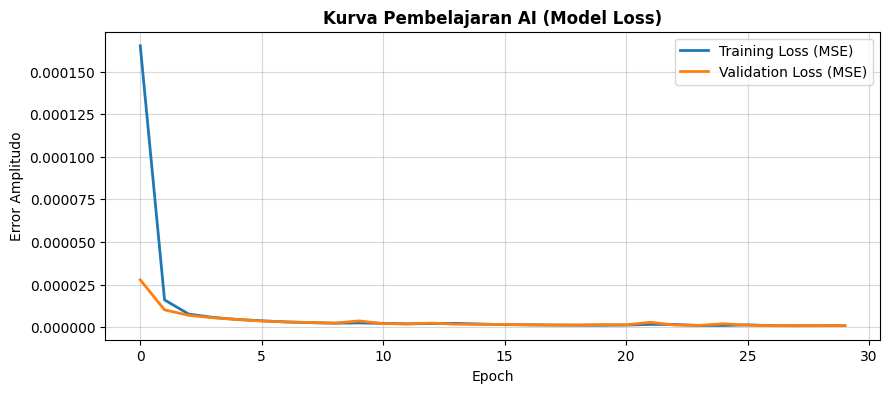

Melakukan prediksi pada data validasi...
4/4 [==============================] - 1s 229ms/step


C:\Users\kunde\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



[OK] Model AI berhasil disimpan ke 'unet_avo_denoising_model.h5'


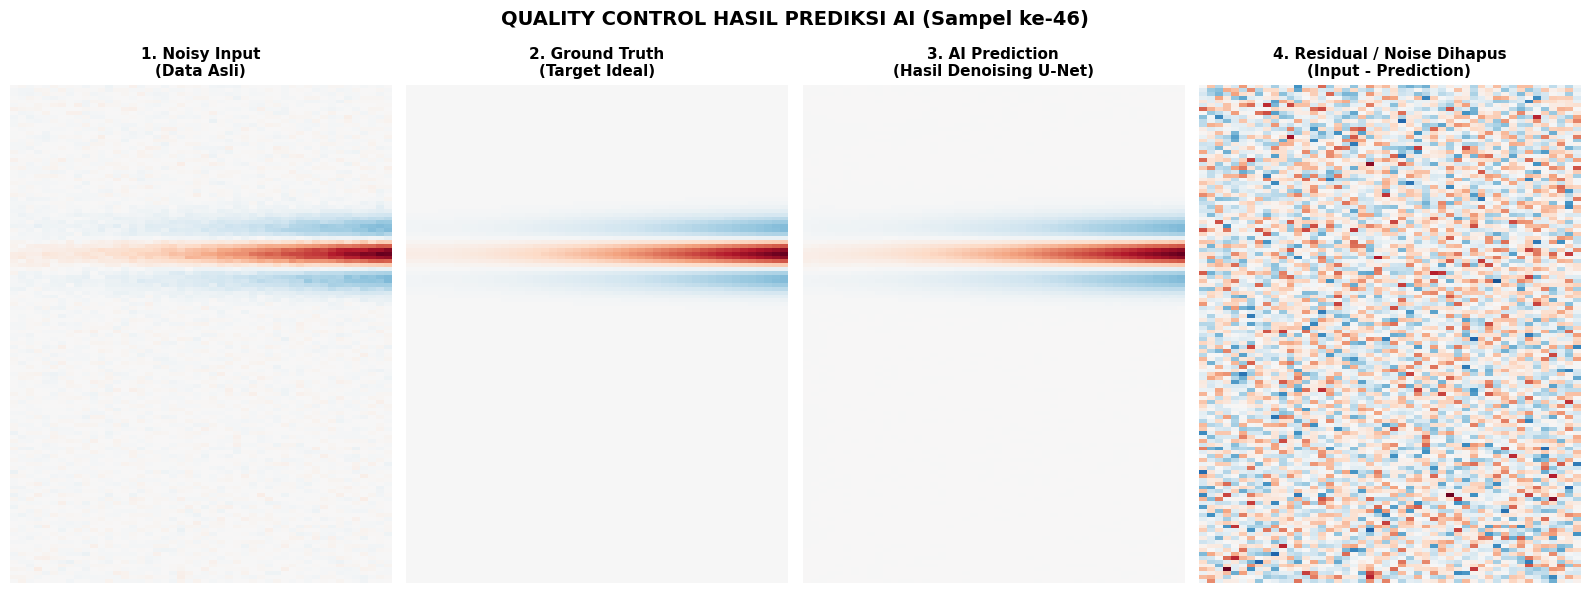

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNGSI GEOFISIKA (Untuk Data Generator)
# ==========================================
def ricker_wavelet(f, dt, length):
    t = np.arange(-length/2, (length-dt)/2, dt)
    return t, (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))

def aki_richards_avo(vp1, vs1, rho1, vp2, vs2, rho2, angles_deg):
    theta_rad = np.radians(angles_deg)
    dvp, dvs, drho = vp2 - vp1, vs2 - vs1, rho2 - rho1
    vp, vs, rho = (vp1 + vp2) / 2.0, (vs1 + vs2) / 2.0, (rho1 + rho2) / 2.0
    A = 0.5 * (dvp/vp + drho/rho)
    B = 0.5 * (dvp/vp) - 4 * (vs/vp)**2 * (dvs/vs) - 2 * (vs/vp)**2 * (drho/rho)
    return A + B * np.sin(theta_rad)**2

# ==========================================
# 2. DATASET GENERATOR (SKALA BESAR)
# ==========================================
# Menggunakan dimensi yang ramah U-Net (bisa dibagi 2, 4, 8)
n_samples = 128  # Sumbu Y (Waktu)
n_angles = 48    # Sumbu X (Sudut 0-47 derajat)
dt = 0.002
angles = np.arange(0, n_angles, 1)

def generate_dataset(num_gathers):
    print(f"Membangun {num_gathers} pasangan data seismik sintetik...")
    X = np.zeros((num_gathers, n_samples, n_angles, 1)) # Input (Noisy)
    Y = np.zeros((num_gathers, n_samples, n_angles, 1)) # Target (Clean)
    
    t_wav, wavelet = ricker_wavelet(30.0, dt, 0.1)
    
    for i in range(num_gathers):
        # Mengacak properti batuan agar AI belajar variasi, bukan menghafal
        vp1, vs1, rho1 = np.random.uniform(2500, 3200), np.random.uniform(1200, 1600), np.random.uniform(2.3, 2.5)
        vp2, vs2, rho2 = np.random.uniform(2200, 3500), np.random.uniform(1100, 2200), np.random.uniform(2.1, 2.4)
        
        R_theta = aki_richards_avo(vp1, vs1, rho1, vp2, vs2, rho2, angles)
        
        # Posisi reflektor diacak sedikit agar AI belajar fitur translasi invarian
        target_idx = np.random.randint(40, 80)
        
        reflectivity = np.zeros((n_samples, n_angles))
        reflectivity[target_idx, :] = R_theta
        
        clean_gather = np.zeros_like(reflectivity)
        for j in range(n_angles):
            clean_gather[:, j] = np.convolve(reflectivity[:, j], wavelet, mode='same')
            
        # Mengacak tingkat Noise (SNR bervariasi antara 5 hingga 15 dB)
        snr_db = np.random.uniform(5, 15)
        signal_power = np.mean(clean_gather**2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(noise_power), clean_gather.shape)
        
        noisy_gather = clean_gather + noise
        
        # Reshape untuk TensorFlow (menambahkan channel dimensi)
        X[i, :, :, 0] = noisy_gather
        Y[i, :, :, 0] = clean_gather
        
    return X, Y

# Generate 500 sampel untuk Training dan 100 sampel untuk Validation
X_train, Y_train = generate_dataset(500)
X_val, Y_val = generate_dataset(100)
print(f"Shape X_train: {X_train.shape}")


# ==========================================
# 3. MEMBANGUN ARSITEKTUR U-NET (2D CNN)
# ==========================================
def build_unet(input_shape=(128, 48, 1)):
    inputs = layers.Input(shape=input_shape)

    # --- ENCODER (Downsampling) ---
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1) # Output: 64x24

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2) # Output: 32x12

    # --- BOTTLENECK ---
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # --- DECODER (Upsampling + Skip Connections) ---
    u4 = layers.UpSampling2D((2, 2))(c3) # Output: 64x24
    u4 = layers.concatenate([u4, c2])    # Skip Connection dari c2!
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D((2, 2))(c4) # Output: 128x48
    u5 = layers.concatenate([u5, c1])    # Skip Connection dari c1!
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    # --- OUTPUT LAYER ---
    # Linear activation karena ini regresi nilai amplitudo seismik, bukan klasifikasi
    outputs = layers.Conv2D(1, (1, 1), activation='linear')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    
    # Menggunakan MSE (Mean Squared Error) untuk penalti selisih amplitudo
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_unet()
model.summary()


# ==========================================
# 4. TRAINING MODEL
# ==========================================
print("\nMemulai proses training...")
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,           # Jumlah iterasi pembelajaran
    batch_size=16,       # Jumlah sampel per update bobot
    verbose=1
)


# ==========================================
# 5. VISUALISASI HASIL TRAINING & PREDIKSI
# ==========================================
# A. Plot Kurva Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss (MSE)', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
plt.title('Kurva Pembelajaran AI (Model Loss)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Error Amplitudo')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# B. Prediksi Data Validation
print("Melakukan prediksi pada data validasi...")
predictions = model.predict(X_val)

# Ambil 1 sampel acak untuk visualisasi QC
test_idx = np.random.randint(0, len(X_val))
sample_input = X_val[test_idx, :, :, 0]
sample_target = Y_val[test_idx, :, :, 0]
sample_pred = predictions[test_idx, :, :, 0]
sample_residual = sample_input - sample_pred

# Fungsi bantuan untuk plot seismik (sama seperti sebelumnya)
def plot_gather(ax, data, title):
    vmax = np.max(np.abs(data)) if np.max(np.abs(data)) != 0 else 1.0
    im = ax.imshow(data, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    return im

# Visualisasi 4-Panel untuk QC
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
plt.suptitle(f"QUALITY CONTROL HASIL PREDIKSI AI (Sampel ke-{test_idx})", fontsize=14, fontweight='bold')

plot_gather(axes[0], sample_input, "1. Noisy Input\n(Data Asli)")
plot_gather(axes[1], sample_target, "2. Ground Truth\n(Target Ideal)")
plot_gather(axes[2], sample_pred, "3. AI Prediction\n(Hasil Denoising U-Net)")
plot_gather(axes[3], sample_residual, "4. Residual / Noise Dihapus\n(Input - Prediction)")
# --- TAMBAHKAN INI SETELAH model.fit ---
model.save("unet_avo_denoising_model.h5")
print("\n[OK] Model AI berhasil disimpan ke 'unet_avo_denoising_model.h5'")
plt.tight_layout()
plt.show()

Berhasil memuat model dari unet_avo_denoising_model.h5
Membangun data Blind Test...
AI sedang melakukan prediksi pada data blind test...
1/1 [==============================] - 0s 146ms/step


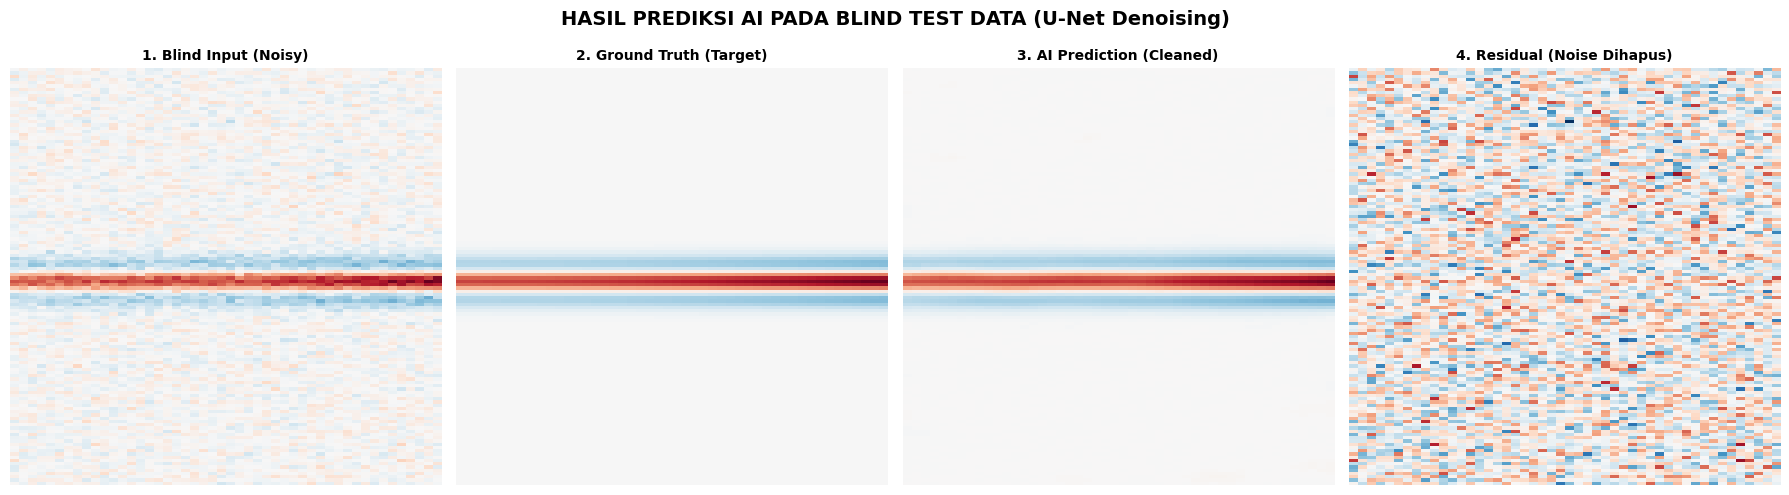

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# 1. Load Model yang sudah disimpan
model_path = "unet_avo_denoising_model.h5"
if not os.path.exists(model_path):
    raise FileNotFoundError("File model tidak ditemukan. Pastikan Anda sudah menjalankan proses save model.")

model = tf.keras.models.load_model(model_path)
print(f"Berhasil memuat model dari {model_path}")

# 2. Persiapan Data Blind Test (Parameter yang berbeda dari training)
# Kita gunakan frekuensi 35Hz (Training 30Hz) dan SNR lebih rendah (lebih kotor)
n_samples, n_angles = 128, 48
dt = 0.002
angles = np.arange(0, n_angles, 1)

def generate_blind_test():
    print("Membangun data Blind Test...")
    # Skenario Geologi Baru: Reservoir yang lebih dalam/lunak
    # Parameter digeser dari range training untuk menguji generalisasi
    vp1, vs1, rho1 = 3300, 1700, 2.45
    vp2, vs2, rho2 = 2500, 1900, 2.10 # Kontras kuat untuk tes AVO Kelas III
    
    # Hitung Aki-Richards
    theta_rad = np.radians(angles)
    dvp, dvs, drho = vp2 - vp1, vs2 - vs1, rho2 - rho1
    vp, vs, rho = (vp1 + vp2) / 2.0, (vs1 + vs2) / 2.0, (rho1 + rho2) / 2.0
    A = 0.5 * (dvp/vp + drho/rho)
    B = 0.5 * (dvp/vp) - 4 * (vs/vp)**2 * (dvs/vs) - 2 * (vs/vp)**2 * (drho/rho)
    R_theta = A + B * np.sin(theta_rad)**2
    
    # Buat Seismik (35 Hz Ricker)
    t = np.arange(-0.05, 0.05, dt)
    f = 35.0
    wavelet = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    
    clean = np.zeros((n_samples, n_angles))
    clean[64, :] = R_theta
    for j in range(n_angles):
        clean[:, j] = np.convolve(clean[:, j], wavelet, mode='same')
        
    # Tambahkan Noise Berat (SNR 6 dB)
    snr_db = 6.0
    sig_p = np.mean(clean**2)
    noi_p = sig_p / (10 ** (snr_db / 10))
    noisy = clean + np.random.normal(0, np.sqrt(noi_p), clean.shape)
    
    return noisy.reshape(1, 128, 48, 1), clean.reshape(1, 128, 48, 1)

X_blind, Y_blind = generate_blind_test()

# 3. Prediksi (Denoising)
print("AI sedang melakukan prediksi pada data blind test...")
prediction = model.predict(X_blind)

# 4. Visualisasi Hasil Evaluasi
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
plt.suptitle("HASIL PREDIKSI AI PADA BLIND TEST DATA (U-Net Denoising)", fontsize=14, fontweight='bold')

def plot_res(ax, data, title):
    vmax = np.max(np.abs(data))
    ax.imshow(data[0, :, :, 0], aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plot_res(axes[0], X_blind, "1. Blind Input (Noisy)")
plot_res(axes[1], Y_blind, "2. Ground Truth (Target)")
plot_res(axes[2], prediction, "3. AI Prediction (Cleaned)")
plot_res(axes[3], X_blind - prediction, "4. Residual (Noise Dihapus)")

plt.tight_layout()
plt.show()

Membangun 500 matriks data (kombinasi variasi Kelas I-IV)...
Membangun 100 matriks data (kombinasi variasi Kelas I-IV)...

Memulai proses komputasi Training AI...
Epoch 1/30
32/32 [==============================] - 16s 456ms/step - loss: 1.4099e-04 - mae: 0.0056 - val_loss: 2.1302e-05 - val_mae: 0.0028
Epoch 2/30
32/32 [==============================] - 23s 723ms/step - loss: 1.2261e-05 - mae: 0.0019 - val_loss: 7.3131e-06 - val_mae: 0.0016
Epoch 3/30
32/32 [==============================] - 17s 531ms/step - loss: 5.4601e-06 - mae: 0.0014 - val_loss: 4.0620e-06 - val_mae: 0.0012
Epoch 4/30
32/32 [==============================] - 17s 529ms/step - loss: 3.2533e-06 - mae: 0.0011 - val_loss: 2.6450e-06 - val_mae: 0.0011
Epoch 5/30
32/32 [==============================] - 17s 536ms/step - loss: 2.4135e-06 - mae: 0.0010 - val_loss: 2.1533e-06 - val_mae: 9.6014e-04
Epoch 6/30
32/32 [==============================] - 18s 578ms/step - loss: 2.0181e-06 - mae: 9.1676e-04 - val_loss: 2.3941e-06 -

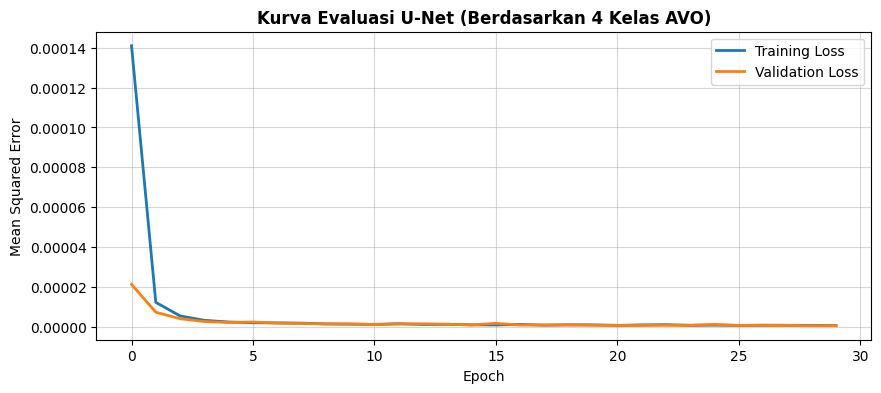

4/4 [==============================] - 1s 183ms/step


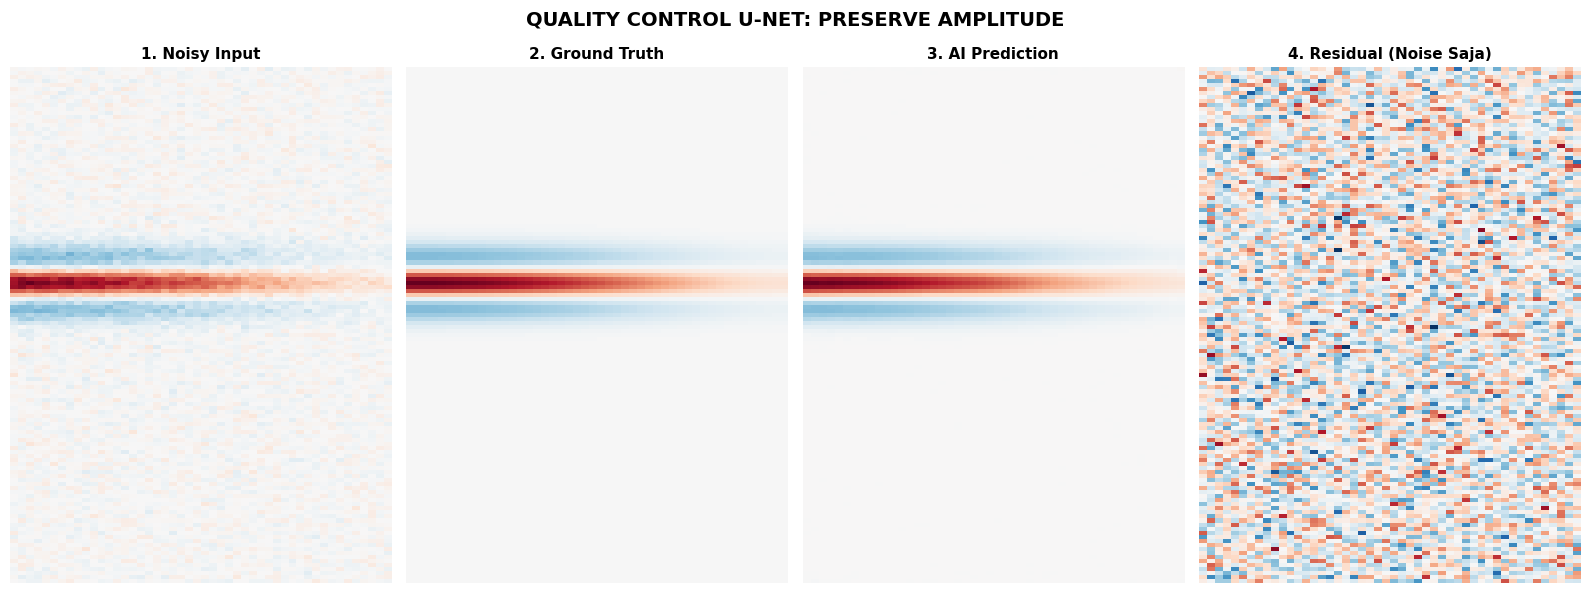

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNGSI MATEMATIS & GEOFISIKA
# ==========================================
def ricker_wavelet(f, dt, length):
    t = np.arange(-length/2, (length-dt)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y

def aki_richards_avo(vp1, vs1, rho1, vp2, vs2, rho2, theta_deg):
    theta_rad = np.radians(theta_deg)
    dvp, dvs, drho = vp2 - vp1, vs2 - vs1, rho2 - rho1
    vp, vs, rho = (vp1 + vp2) / 2.0, (vs1 + vs2) / 2.0, (rho1 + rho2) / 2.0
    A = 0.5 * (dvp/vp + drho/rho)
    B = 0.5 * (dvp/vp) - 4 * (vs/vp)**2 * (dvs/vs) - 2 * (vs/vp)**2 * (drho/rho)
    C = 0.5 * (dvp/vp)
    return A + B * np.sin(theta_rad)**2 + C * (np.sin(theta_rad)**2 * np.tan(theta_rad)**2)

# ==========================================
# 2. MASS DATASET GENERATOR BERBASIS KELAS AVO
# ==========================================
# Penyesuaian Dimensi untuk U-Net (128x48)
dt = 0.002
n_samples = 128
n_angles = 48
angles = np.arange(0, n_angles, 1)

# Database Fondasi (Sesuai kodingan Anda)
base_classes = [
    {'vp1': 3000, 'vs1': 1400, 'rho1': 2.40, 'vp2': 3600, 'vs2': 2300, 'rho2': 2.25}, # Kelas I
    {'vp1': 2900, 'vs1': 1400, 'rho1': 2.35, 'vp2': 2800, 'vs2': 1700, 'rho2': 2.20}, # Kelas II
    {'vp1': 2700, 'vs1': 1300, 'rho1': 2.35, 'vp2': 2400, 'vs2': 1600, 'rho2': 2.15}, # Kelas III
    {'vp1': 3200, 'vs1': 1600, 'rho1': 2.40, 'vp2': 2600, 'vs2': 1100, 'rho2': 2.10}  # Kelas IV
]

def generate_mass_dataset(num_gathers):
    print(f"Membangun {num_gathers} matriks data (kombinasi variasi Kelas I-IV)...")
    X = np.zeros((num_gathers, n_samples, n_angles, 1))
    Y = np.zeros((num_gathers, n_samples, n_angles, 1))
    
    t_wav, wavelet = ricker_wavelet(30.0, dt, 0.1)
    
    for i in range(num_gathers):
        # 1. Pilih salah satu kelas dasar secara acak
        base = base_classes[np.random.randint(0, len(base_classes))]
        
        # 2. Beri variasi acak (± 5%) agar AI belajar generalisasi, bukan menghafal
        vp1 = base['vp1'] * np.random.uniform(0.95, 1.05)
        vs1 = base['vs1'] * np.random.uniform(0.95, 1.05)
        rho1 = base['rho1'] * np.random.uniform(0.95, 1.05)
        vp2 = base['vp2'] * np.random.uniform(0.95, 1.05)
        vs2 = base['vs2'] * np.random.uniform(0.95, 1.05)
        rho2 = base['rho2'] * np.random.uniform(0.95, 1.05)
        
        R_theta = aki_richards_avo(vp1, vs1, rho1, vp2, vs2, rho2, angles)
        
        # 3. Posisikan reflektor secara acak di kedalaman (waktu) yang wajar
        target_idx = np.random.randint(40, 88)
        
        reflectivity = np.zeros((n_samples, n_angles))
        reflectivity[target_idx, :] = R_theta
        
        clean_gather = np.zeros_like(reflectivity)
        for j in range(n_angles):
            clean_gather[:, j] = np.convolve(reflectivity[:, j], wavelet, mode='same')
            
        # 4. Tambahkan noise (SNR acak antara 5 dB hingga 15 dB)
        snr_db = np.random.uniform(5.0, 15.0)
        signal_power = np.mean(clean_gather**2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(noise_power), clean_gather.shape)
        
        X[i, :, :, 0] = clean_gather + noise
        Y[i, :, :, 0] = clean_gather
        
    return X, Y

# Membangun 600 total data
X_train, Y_train = generate_mass_dataset(500)
X_val, Y_val = generate_mass_dataset(100)


# ==========================================
# 3. MEMBANGUN ARSITEKTUR U-NET
# ==========================================
def build_unet(input_shape=(128, 48, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # Decoder
    u4 = layers.UpSampling2D((2, 2))(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='linear')(c5)
    model = models.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_unet()


# ==========================================
# 4. TRAINING MODEL & PENYIMPANAN
# ==========================================
print("\nMemulai proses komputasi Training AI...")
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=16,
    verbose=1
)

# Menyimpan model (WAJIB agar tidak hilang)
model.save("unet_avo_denoising_model.h5")
print("\n[OK] Pelatihan selesai. Model disimpan sebagai 'unet_avo_denoising_model.h5'")


# ==========================================
# 5. VISUALISASI HASIL (KURVA & GATHER)
# ==========================================
# Kurva Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Kurva Evaluasi U-Net (Berdasarkan 4 Kelas AVO)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# Visualisasi Prediksi Acak
predictions = model.predict(X_val)
test_idx = np.random.randint(0, len(X_val))

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
plt.suptitle("QUALITY CONTROL U-NET: PRESERVE AMPLITUDE", fontsize=14, fontweight='bold')

def plot_gather(ax, data, title):
    vmax = np.max(np.abs(data)) if np.max(np.abs(data)) != 0 else 1.0
    ax.imshow(data, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plot_gather(axes[0], X_val[test_idx, :, :, 0], "1. Noisy Input")
plot_gather(axes[1], Y_val[test_idx, :, :, 0], "2. Ground Truth")
plot_gather(axes[2], predictions[test_idx, :, :, 0], "3. AI Prediction")
plot_gather(axes[3], X_val[test_idx, :, :, 0] - predictions[test_idx, :, :, 0], "4. Residual (Noise Saja)")

plt.tight_layout()
plt.show()